In [1]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"using device : {device}")

c:\py\Anaconda3\envs\proximity_cf\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


using device : cpu


## Models

- model definition 
- weight loading

In [3]:
## model definition

import torch.nn as nn

class NineLayerMLP(nn.Module):
    def __init__(self, input_dim):
        super(NineLayerMLP, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 32),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(32, 16),
            nn.ReLU(),

            nn.Linear(16, 16),
            nn.ReLU(),
            nn.Dropout(0.1),

            # output layer
            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

In [4]:
# model loading

model_load2 = NineLayerMLP(input_dim=8)
model_load2.load_state_dict(torch.load(
    '../results/Weights/model2_smotetraining.pth',
    map_location='cpu'
))
model_load2.eval()

NineLayerMLP(
  (model): Sequential(
    (0): Linear(in_features=8, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=128, out_features=64, bias=True)
    (7): ReLU()
    (8): Linear(in_features=64, out_features=64, bias=True)
    (9): ReLU()
    (10): Dropout(p=0.2, inplace=False)
    (11): Linear(in_features=64, out_features=32, bias=True)
    (12): ReLU()
    (13): Linear(in_features=32, out_features=32, bias=True)
    (14): ReLU()
    (15): Dropout(p=0.1, inplace=False)
    (16): Linear(in_features=32, out_features=16, bias=True)
    (17): ReLU()
    (18): Linear(in_features=16, out_features=16, bias=True)
    (19): ReLU()
    (20): Dropout(p=0.1, inplace=False)
    (21): Linear(in_features=16, out_features=1, bias=True)
    (22): Sigmoid()
  )
)

## Dataset

In [5]:
# we will use whole dataset for prediction

import pandas as pd
import numpy as np
# shuffle
from sklearn.utils import shuffle

file_path2 = '../Datasets/diabetes.csv'

df2 = pd.read_csv(file_path2)

# shuffle
df2 = shuffle(df2, random_state=42).reset_index(drop=True)
# drop duplicates
df2 = df2.drop_duplicates()

X2_df = df2.drop(columns=['Outcome'])   
X2 = X2_df.values.astype(np.float32) 
y2 = df2['Outcome'].values.astype(np.float32)

X_tensor2 = torch.tensor(X2)

## Pipeline

- ML classifier
- Interface
- AI expainer (LIME / SHAP) 
    - LIME : (https://safjan.com/lime-tutorial/), (https://github.com/marcotcr/lime)
    - SHAP : https://shap.readthedocs.io/en/latest/
- Dice (https://interpret.ml/DiCE/notebooks/DiCE_model_agnostic_CFs.html)
- counterfactual examples

## User-feedback constraints

- two steps method
    - before DiCE : filter features which can be changed
    - after DiCE : visualize some linear constraints (e.g. for BMI)
        - use PCA first;
        - map constraints on 2-D space;

In [6]:
print(df2.columns.tolist())

['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']


'Pregnancies' : 

'Glucose'

'BloodPressure'

'SkinThickness'

'Insulin'

'BMI' ： 18.5 < x < 35

'DiabetesPedigreeFunction'

'Age' : cannot change

'Outcome'

In [ ]:
modifiable_features = [
    'Pregnancies', 'Glucose', 'BloodPressure', 
    'SkinThickness', 'Insulin', 'BMI', 
    'DiabetesPedigreeFunction'
]

In [8]:
whole_features = df2.columns.tolist()

print(set(modifiable_features).issubset(set(whole_features)))

True


## Scatter plot for LIME & SHAP

LIME and SHAP comparison :

- 200 samples from dataset2 (0 -> 1)

### For Dataset 2

In [9]:
## we can prepare index list at first 

### for dataset 2
import torch
import numpy as np

target_class = 0           
threshold = 0.5           

model_load2.eval()
with torch.no_grad():
    probs = model_load2(X_tensor2.to(device)).cpu().numpy().flatten()

if target_class == 0:
    indices = np.where(probs < threshold)[0]
else:
    indices = np.where(probs >= threshold)[0]

# store in list
negative_indices_1 = indices.tolist()

print(len(negative_indices_1))

632


In [10]:
import re
import lime
import shap
import torch
import numpy as np
import dice_ml
from dice_ml import Dice
import pandas as pd

c:\py\Anaconda3\envs\proximity_cf\lib\site-packages\shap\utils\_clustering.py:35: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  def _pt_shuffle_rec(i, indexes, index_mask, partition_tree, M, pos):
c:\py\Anaconda3\envs\proximity_cf\lib\site-packages\shap\utils\_clustering.py:54: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  def delta_minimization_order(all_masks,

In [11]:
## for LIME and SHAP

def predict_fn_lime(x):
    with torch.no_grad():
        x_tensor = torch.tensor(x, dtype=torch.float32).to(device)
        probs = model_load2(x_tensor)
        probs = torch.cat([1 - probs, probs], dim=1)
        return probs.cpu().numpy()
    
def shap_predict_fn(x_numpy):
    with torch.no_grad():
        x_tensor = torch.tensor(x_numpy, dtype=torch.float32).to(device)
        probs = model_load2(x_tensor)
        return torch.cat([1 - probs, probs], dim=1).cpu().numpy()

In [12]:
# LIME for dataset 2
## output --> feature list

def LIME_ds1(sample):
    ## LIME
    explainer_lime = lime.lime_tabular.LimeTabularExplainer(
        training_data=X_tensor2.cpu().numpy(),
        feature_names=list(X2_df.columns),
        class_names=['No Diabetes', 'Diabetes'],
        mode='classification'
    )

    exp_lime = explainer_lime.explain_instance(
        data_row=sample.flatten(),
        predict_fn=predict_fn_lime,
        num_features=8
    )

    positive_feature_lime = [
        token for feature, weight in exp_lime.as_list() if weight < 0
        for token in re.split(r'\s|<|>|=', feature)
        if re.match(r'^[A-Za-z_]+$', token)
    ]

    return positive_feature_lime

In [13]:
# SHAP for dataset2
## output --> feature list

def SHAP_ds1(sample):
    background_raw = X_tensor2.cpu().numpy()

    background = shap.kmeans(background_raw, 50)

    explainer_shap = shap.KernelExplainer(
        model=shap_predict_fn,
        data=background
    )

    shap_values = explainer_shap.shap_values(sample)
    shap_value_class1 = shap_values[1][0]
    feature_names = list(X2_df.columns)
    positive_features = [
        (name, value)
        for name, value in zip(feature_names, shap_value_class1)
        if value < 0
    ]

    positive_feature_names = [name for name, value in positive_features]

    return positive_feature_names
    

In [14]:
# DiCE
## input --> featrues list
## output --> counterfactual example sets

class PyTorchWrapper(torch.nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model.eval()

    def forward(self, input_tensor):
        return self.model(input_tensor)

    def predict_proba(self, input_data):
        if isinstance(input_data, pd.DataFrame):
            input_data = input_data.values

        if isinstance(input_data, np.ndarray):
            input_tensor = torch.tensor(input_data, dtype=torch.float32).to(device)
        else:
            raise ValueError("Unsupported input type for predict_proba")

        with torch.no_grad():
            output = self.model(input_tensor)  
            probs = torch.cat([1 - output, output], dim=1)
        return probs.cpu().numpy()
    
import contextlib
import io
import warnings

def DICE_ds1(feature_names, sample):
    try:
        # human-feedback contraints
        if not set(feature_names).issubset(set(modifiable_features)):
            return None

        data_dice = dice_ml.Data(
            dataframe=df2,
            continuous_features=[col for col in df2.columns if col != 'Outcome'],
            outcome_name='Outcome'
        )

        model_wrapper = PyTorchWrapper(model_load2)
        model_dice = dice_ml.Model(model=model_wrapper, backend="PYT")
        dice = Dice(data_dice, model_dice)

        sample_df = pd.DataFrame(sample, columns=[col for col in df2.columns if col != 'Outcome'])

        with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")  
                dice_exp = dice.generate_counterfactuals(
                    sample_df, 
                    total_CFs=1,
                    desired_class="opposite",
                    features_to_vary=feature_names,
                    # stopping_threshold=0.01,
                    # proximity_weight=5.0,          
                    # posthoc_sparsity_param=0.8,    
                    # diversity_weight=0.0, 
                    verbose=False
                )

        cf_df = dice_exp.cf_examples_list[0].final_cfs_df
        if cf_df is None or cf_df.empty:
            print("cf_df is none here")
            return None

        cf_df = cf_df.drop(columns=["Outcome"], errors="ignore")
        return cf_df

    except Exception as e:
        # print("what the hell?")
        return None

In [15]:
# LIME again
## input --> counterfactual example
## output --> probability from LIME

def LIME_prob(cf_df):
    if isinstance(cf_df, pd.DataFrame):
        sample = cf_df.to_numpy()
    elif isinstance(cf_df, pd.Series):
        sample = cf_df.values.reshape(1, -1)
    elif isinstance(cf_df, np.ndarray):
        sample = cf_df.reshape(1, -1)
    else:
        raise TypeError("Unsupported input type")

    probs = predict_fn_lime(sample)  
    return probs[0][1]

In [16]:
# SHAP again
## input --> counterfactual example
## output --> probability from SHAP

def SHAP_prob(cf_df):
    if isinstance(cf_df, pd.DataFrame):
        sample = cf_df.to_numpy()
    elif isinstance(cf_df, pd.Series):
        sample = cf_df.values.reshape(1, -1)
    elif isinstance(cf_df, np.ndarray):
        sample = cf_df.reshape(1, -1)
    else:
        raise TypeError("Unsupported input type")

    probs = shap_predict_fn(sample)  
    return probs[0][1]

### Testing

In [17]:
import matplotlib.pyplot as plt
import numpy as np

def plot_comprison(shap_result, lime_result) -> None:

    indices = np.arange(len(shap_result))

    plt.figure(figsize=(14, 6))

    plt.scatter(indices, shap_result, facecolors='none', edgecolors='blue', label='SHAP CF predictions')
    plt.scatter(indices, lime_result, facecolors='none', edgecolors='red', label='LIME CF predictions')

    plt.axhline(y=0.5, color='green', linestyle='--', linewidth=2, alpha=0.8, label='Decision Boundary')

    plt.xticks(np.arange(0, len(shap_result), 10))

    plt.ylim(0.3, 0.8)
    plt.xlabel('Sample Index')
    plt.ylabel('Predicted Probabilities')
    plt.title('Comparison of SHAP and LIME Results with Decision Boundary')
    plt.legend()
    plt.show()

In [38]:
import numpy as np
import torch

def _as_numpy(x):
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return np.asarray(x)

def _sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def _to_pos_prob(y_pred, pos_index=1):
    """
    Normalize outputs to positive-class probability (n,).
    Accepts proba or logits shaped (n,), (n,1), (n,2).
    If (n,2), use column `pos_index` as positive class.
    If values look like logits in (n,), apply sigmoid.
    """
    arr = _as_numpy(y_pred)

    # Ensure 2D
    if arr.ndim == 1:
        arr = arr.reshape(-1, 1)

    n, m = arr.shape
    if m == 1:
        col = arr[:, 0]
        if (col < -1e-6).any() or (col > 1 + 1e-6).any():
            col = _sigmoid(col)
        return col
    elif m == 2:
        col = arr[:, pos_index]
        if (col < -1e-6).any() or (col > 1 + 1e-6).any():
            col = _sigmoid(col)
        return col
    else:
        raise ValueError(f"Unsupported predict_proba/logit shape: {arr.shape}")

def _logit(p, eps=1e-12):
    p = np.clip(p, eps, 1 - eps)
    return np.log(p) - np.log(1 - p)

def compute_cf_metrics(
    orig,
    cf,
    model_proba_fn,                # callable: np.ndarray -> (proba or logits) ndarray
    *,
    target_label=1,                # desired class (binary)
    decision_threshold=0.5,        # tuned on validation set
    pos_index=1,                   # if predict_proba returns (n,2)
    modifiable_mask=None,          # boolean array, True if feature can change
    action_set=None,               # reserved for logging
    onehot_groups=None,            # list of lists, each sublist indices for a one-hot group
    feature_bounds=None,           # list of (low, high) or None per feature
    cost_weights=None,             # per-feature weights for weighted L1/L2
    scaler=None,                   # optional sklearn scaler fitted on training data
    epsilon=1e-6,                  # absolute tolerance in raw space
    use_std_change=True,           # detect 'changed' in standardized space when scaler is given
    eps_std=5e-3,                  # tolerance in standardized space
    ae_model=None,                 # torch AE; expects eval()'d
    ae_device="cpu",
    ae_on_std=False                # whether AE expects standardized inputs
):
    """
    Returns a dict of CF quality metrics for binary classification.
    """

    orig = np.asarray(orig, dtype=float).reshape(1, -1)
    cf   = np.asarray(cf,   dtype=float).reshape(1, -1)
    d    = orig.shape[1]

    # ---- Model probabilities ----
    p_orig = _to_pos_prob(model_proba_fn(orig), pos_index=pos_index)  # (1,)
    p_cf   = _to_pos_prob(model_proba_fn(cf),   pos_index=pos_index)  # (1,)
    y_orig = int(p_orig[0] >= decision_threshold)
    y_cf   = int(p_cf[0]   >= decision_threshold)

    # ---- Validity ----
    validity = int(y_cf == int(target_label))  # target-based validity (kept)

    # >>> CHANGED: add flip-based validity (strictly requires a flip)
    flip_validity = int((y_cf == int(target_label)) and (y_orig != int(target_label)))

    # ---- Probability gain / margins ----
    direction = +1 if target_label == 1 else -1
    prob_gain = float(direction * (p_cf[0] - p_orig[0]))  # toward target (+ better)

    prob_margin_before = float(abs(p_orig[0] - decision_threshold))
    prob_margin_after  = float(abs(p_cf[0]   - decision_threshold))

    # >>> CHANGED: Logit margins reported as absolute distance to threshold in logit space
    logit_thr = _logit(decision_threshold)
    logit_margin_before = float(abs(_logit(p_orig[0]) - logit_thr))
    logit_margin_after  = float(abs(_logit(p_cf[0])   - logit_thr))

    # ---- Domain clipping violations ----
    bound_violations = 0
    if feature_bounds is not None:
        for j in range(d):
            bounds = feature_bounds[j]
            if bounds is None:
                continue
            lo, hi = bounds
            if lo is not None and cf[0, j] < lo - 1e-12:
                bound_violations += 1
            if hi is not None and cf[0, j] > hi + 1e-12:
                bound_violations += 1

    # ---- One-hot group validity ----
    onehot_violations = 0
    if onehot_groups:
        for grp in onehot_groups:
            vals = cf[0, grp]
            near0 = np.isclose(vals, 0.0, atol=1e-3)
            near1 = np.isclose(vals, 1.0, atol=1e-3)
            if not (near1.sum() == 1 and near0.sum() == (len(grp) - 1)):
                onehot_violations += 1

    # ---- Actionability violations / Sparsity ----
    mod_mask = None
    if modifiable_mask is not None:
        mod_mask = np.asarray(modifiable_mask, dtype=bool).reshape(1, -1)

    diff = (cf - orig).reshape(-1)

    if scaler is not None and use_std_change:
        orig_std = scaler.transform(orig)
        cf_std   = scaler.transform(cf)
        delta_std = (cf_std - orig_std).reshape(-1)
        changed = np.abs(delta_std) > eps_std
    else:
        changed = np.abs(diff) > epsilon

    changed = changed.reshape(1, -1)

    immut_violation = 0
    if mod_mask is not None:
        immut_violation = int((changed & (~mod_mask)).sum())
        sparsity = int((changed & mod_mask).sum())
    else:
        sparsity = int(changed.sum())

    # ---- Proximity (raw) ----
    if cost_weights is not None:
        w = np.asarray(cost_weights, dtype=float).reshape(-1)
        w = np.clip(w, 1e-12, None)
        prox_l1 = float(np.sum(w * np.abs(diff)))
        prox_l2 = float(np.sqrt(np.sum(w * (diff ** 2))))
    else:
        prox_l1 = float(np.sum(np.abs(diff)))
        prox_l2 = float(np.linalg.norm(diff))

    # ---- Proximity (standardized) ----
    prox_l1_std = prox_l2_std = None
    if scaler is not None:
        delta_std = (scaler.transform(cf) - scaler.transform(orig)).reshape(-1)
        prox_l1_std = float(np.sum(np.abs(delta_std)))
        prox_l2_std = float(np.linalg.norm(delta_std))

    # ---- Plausibility (AE reconstruction MSE, measured in raw space) ----
    plausibility = None
    if ae_model is not None:
        ae_model.eval()
        with torch.no_grad():
            if scaler is not None and ae_on_std:
                x_in = scaler.transform(cf)
            else:
                x_in = cf
            x_in_t = torch.tensor(x_in, dtype=torch.float32, device=ae_device)
            recon  = ae_model(x_in_t).detach().cpu().numpy()

        if scaler is not None and ae_on_std:
            recon_raw = scaler.inverse_transform(recon)
        else:
            recon_raw = recon

        plausibility = float(np.mean((recon_raw.reshape(-1) - cf.reshape(-1)) ** 2))  # smaller is better

    # ---- Output ----
    out = {
        "validity":                 validity,
        "flip_validity":            flip_validity,        # >>> CHANGED: added
        "y_orig":                   y_orig,
        "y_cf":                     y_cf,
        "p_orig":                   float(p_orig[0]),
        "p_cf":                     float(p_cf[0]),
        "prob_gain_toward_target":  prob_gain,
        "prob_margin_before":       prob_margin_before,
        "prob_margin_after":        prob_margin_after,
        "logit_margin_before":      logit_margin_before,  # >>> CHANGED: now absolute distance
        "logit_margin_after":       logit_margin_after,   # >>> CHANGED: now absolute distance

        "sparsity":                 sparsity,
        "proximity_l1":             prox_l1,
        "proximity_l2":             prox_l2,
        "proximity_l1_std":         prox_l1_std,
        "proximity_l2_std":         prox_l2_std,

        "immutability_violations":  int(immut_violation),
        "bound_violations":         int(bound_violations),
        "onehot_violations":        int(onehot_violations),

        "plausibility_mse":         plausibility
    }

    total_changes = int(changed.sum())
    if mod_mask is not None:
        if total_changes > 0:
            actionable_changes = int((changed & mod_mask).sum())
            out["actionability_score"] = actionable_changes / total_changes
        else:
            out["actionability_score"] = 1.0  # keep original behavior

    return out

In [ ]:
def limeshap_compare_ds1(
    num_sample,
    shap_result=None,
    lime_result=None,
    compute_metrics=True
):
    if shap_result is None:
        shap_result = []
    if lime_result is None:
        lime_result = []

    np.random.seed(42)
    tried_indices = set()
    max_attempts = 20000
    attempt = 0

    all_lime_cfs = []
    all_shap_cfs = []
    lime_metrics_list = []
    shap_metrics_list = []

    while min(len(shap_result), len(lime_result)) < num_sample and attempt < max_attempts:
        attempt += 1
        available_indices = list(set(negative_indices_1) - tried_indices)
        if not available_indices:
            break

        index = sorted(available_indices)[-1]
        tried_indices.add(index)

        sample = X_tensor2[index].numpy().reshape(1, -1)

        # Step 1: LIME / SHAP attribution
        LIME_positive = LIME_ds1(sample)
        SHAP_positive = SHAP_ds1(sample)

        # Step 2: Generate counterfactuals
        cf_df_LIME = DICE_ds1(LIME_positive, sample)
        if cf_df_LIME is None:
            continue
        cf_df_SHAP = DICE_ds1(SHAP_positive, sample)
        if cf_df_SHAP is None:
            continue

        try:
            lime_prob = LIME_prob(cf_df_LIME)
            shap_prob = SHAP_prob(cf_df_SHAP)
        except Exception as e:
            continue

        lime_result.append(lime_prob)
        shap_result.append(shap_prob)

        # Step 3: Add source index
        cf_df_LIME["source_index"] = index
        cf_df_SHAP["source_index"] = index

        all_lime_cfs.append(cf_df_LIME)
        all_shap_cfs.append(cf_df_SHAP)

        # Step 4: Compute evaluation metrics
        if compute_metrics:
            orig_np = sample[0]

            # Drop "source_index" before feeding into model
            lime_np = cf_df_LIME.drop(columns=["source_index"]).iloc[0].to_numpy()
            shap_np = cf_df_SHAP.drop(columns=["source_index"]).iloc[0].to_numpy()

            lime_metrics = compute_cf_metrics(orig_np, lime_np, predict_fn_lime)
            shap_metrics = compute_cf_metrics(orig_np, shap_np, shap_predict_fn)

            lime_metrics["source_index"] = index
            shap_metrics["source_index"] = index

            lime_metrics_list.append(lime_metrics)
            shap_metrics_list.append(shap_metrics)

    # Step 5: Save counterfactuals
    if all_lime_cfs:
        lime_df_all = pd.concat(all_lime_cfs, ignore_index=True)
        lime_df_all.to_csv('./cf samples/LIME_counterfactuals_ds2.csv', index=False)

    if all_shap_cfs:
        shap_df_all = pd.concat(all_shap_cfs, ignore_index=True)
        shap_df_all.to_csv('./cf samples/SHAP_counterfactuals_ds2.csv', index=False)

    # Step 6: Save metrics
    if compute_metrics and lime_metrics_list:
        pd.DataFrame(lime_metrics_list).to_csv('./cf samples/LIME_metrics_ds2.csv', index=False)
    if compute_metrics and shap_metrics_list:
        pd.DataFrame(shap_metrics_list).to_csv('./cf samples/SHAP_metrics_ds2.csv', index=False)

    # Step 7: Optional plotting
    if len(shap_result) == 0:
        return

    plot_comprison(shap_result, lime_result)

    # Return metrics for external use
    return lime_metrics_list, shap_metrics_list

## run

100%|██████████| 1/1 [00:00<00:00,  9.85it/s]


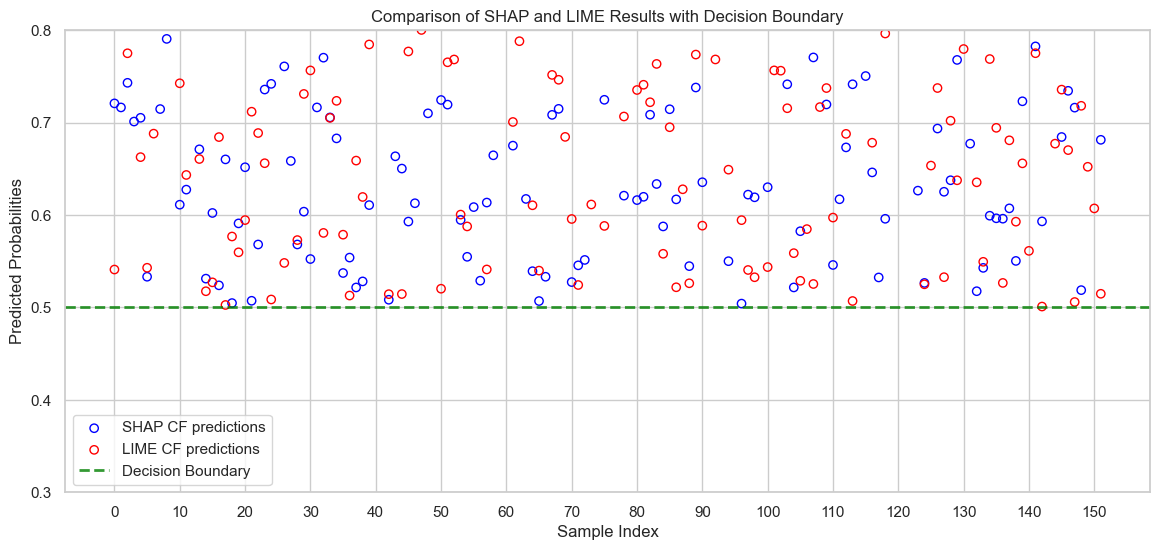

LIME metrics (head):
   validity  flip_validity  y_orig  y_cf    p_orig      p_cf  \
0         1              1       0     1  0.308207  0.541035   
1         1              1       0     1  0.258690  0.859054   
2         1              1       0     1  0.340643  0.775091   
3         1              1       0     1  0.383232  0.855177   
4         1              1       0     1  0.003504  0.662690   

   prob_gain_toward_target  prob_margin_before  prob_margin_after  \
0                 0.232828            0.191793           0.041035   
1                 0.600364            0.241310           0.359054   
2                 0.434448            0.159357           0.275091   
3                 0.471945            0.116768           0.355177   
4                 0.659186            0.496496           0.162690   

   logit_margin_before  ...  sparsity  proximity_l1  proximity_l2  \
0             0.808516  ...         1     55.000000     55.000000   
1             1.052787  ...         2    

In [44]:
import pandas as pd
import numpy as np

# ---- Run experiment ----
shap_result = []
lime_result = []
lime_metrics, shap_metrics = limeshap_compare_ds1(200, shap_result, lime_result)

# ---- Convert to DataFrame ----
df_lime = pd.DataFrame(lime_metrics)
df_shap = pd.DataFrame(shap_metrics)

print("LIME metrics (head):")
print(df_lime.head())

print("\nSHAP metrics (head):")
print(df_shap.head())

# ---- Average values ----
mean_lime = df_lime.mean(numeric_only=True)
mean_shap = df_shap.mean(numeric_only=True)

print("\n===== Average Metrics =====")
print("LIME average metrics:")
print(mean_lime)

print("\nSHAP average metrics:")
print(mean_shap)

# ---- Group margins for clearer comparison ----
margin_cols = [
    "prob_margin_before", "prob_margin_after",
    "logit_margin_before", "logit_margin_after"
]
common_margin_cols = [c for c in margin_cols if c in df_lime.columns and c in df_shap.columns]

if common_margin_cols:
    print("\n===== Margin Comparison (Probability vs Logit space) =====")
    print("LIME margins (average):")
    print(mean_lime[common_margin_cols])
    print("\nSHAP margins (average):")
    print(mean_shap[common_margin_cols])


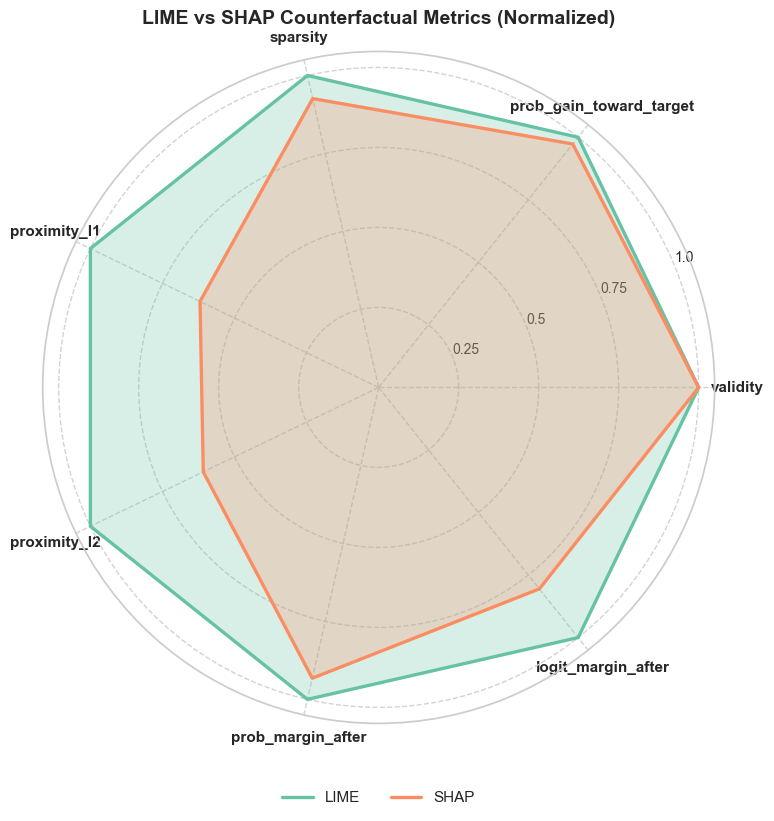

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_cf_radar(
    df_lime, df_shap, 
    metrics=None,
    lower_better=None,
    title="LIME vs SHAP Counterfactual Metrics (Normalized)",
    save_path="lime_shap_radar.png"
):
    """
    Radar chart with max-ratio normalization per metric:
      - For higher-is-better:  norm = v / max(lime, shap)
      - For lower-is-better:   norm = min(lime, shap) / v
    Ensures best=1.0 and the other <1. Skips metrics not present in both frames.
    """

    # 1) default metrics
    if metrics is None:
        metrics = [
            "validity",
            "prob_gain_toward_target",
            "sparsity",
            "proximity_l1",
            "proximity_l2",
            "prob_margin_after",    
            "logit_margin_after",     
            "plausibility_mse"
        ]
    if lower_better is None:
        lower_better = ["sparsity", "proximity_l1", "proximity_l2", "plausibility_mse"]

    # 2) means & common cols）
    lime_mean = df_lime.mean(numeric_only=True)
    shap_mean = df_shap.mean(numeric_only=True)

    metrics = [m for m in metrics if m in lime_mean.index and m in shap_mean.index]
    if not metrics:
        raise ValueError("No common metrics to plot.")
    
    # 3) max-ratio normalization
    eps = 1e-12
    lime_norm, shap_norm = [], []
    for m in metrics:
        lv = float(lime_mean[m]) if pd.notna(lime_mean[m]) else 0.0
        sv = float(shap_mean[m]) if pd.notna(shap_mean[m]) else 0.0

        if m in lower_better:
            base = min(lv, sv)
            ln = base / max(lv, eps)
            sn = base / max(sv, eps)
        else:
            base = max(lv, sv)
            base = base if abs(base) > eps else eps
            ln = lv / base
            sn = sv / base

        lime_norm.append(float(np.clip(ln, 0.0, 1.0)))
        shap_norm.append(float(np.clip(sn, 0.0, 1.0)))

    # 4) close polygon & auto size
    angles = np.linspace(0, 2*np.pi, len(metrics), endpoint=False).tolist()
    angles += angles[:1]
    lime_norm += lime_norm[:1]
    shap_norm += shap_norm[:1]

    k = len(metrics)
    side = float(np.clip(0.55 * k + 4.5, 6.0, 11.0))
    xtick_fs = 11 if k <= 7 else (10 if k <= 10 else 9)

    sns.set_theme(style="whitegrid")
    colors = sns.color_palette("Set2", 2)

    fig, ax = plt.subplots(figsize=(side, side), subplot_kw=dict(polar=True))
    ax.plot(angles, lime_norm, color=colors[0], linewidth=2.4, label="LIME")
    ax.fill(angles, lime_norm, color=colors[0], alpha=0.25)
    ax.plot(angles, shap_norm, color=colors[1], linewidth=2.4, label="SHAP")
    ax.fill(angles, shap_norm, color=colors[1], alpha=0.25)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(metrics, fontsize=xtick_fs, fontweight="bold")
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(["0.25", "0.5", "0.75", "1.0"], fontsize=10)
    ax.set_ylim(0, 1.05)
    ax.grid(color="lightgray", linestyle="--", linewidth=1)

    plt.title(title, size=14, weight="bold", pad=20)
    plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.08), ncol=2, frameon=False)
    plt.tight_layout()

    os.makedirs(os.path.dirname(save_path) or ".", exist_ok=True)
    plt.savefig(save_path, dpi=600, bbox_inches="tight")
    plt.show()

plot_cf_radar(df_lime, df_shap, save_path="./figures/lime_shap_radar_ds2.png")

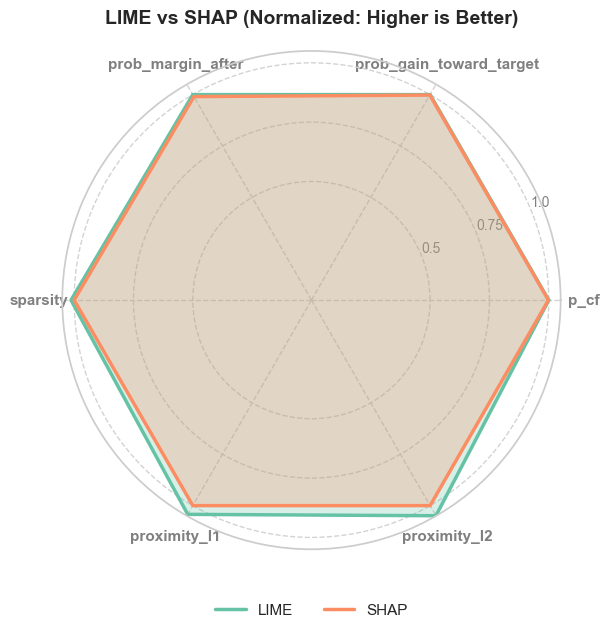

In [27]:
# LIME and SHAP average metrics from the second dataset
metrics2 = [
    "p_cf",
    "prob_gain_toward_target",
    "prob_margin_after",
    "sparsity",
    "proximity_l1",
    "proximity_l2"
]

lime_values2 = [0.587114, 0.369910, 0.087114, 2.270000, 13.308500, 11.545369]
shap_values2 = [0.586276, 0.369072, 0.086276, 2.300000, 13.875000, 12.113264]

# Normalize metrics where "lower is better"
lower_better2 = ["sparsity", "proximity_l1", "proximity_l2"]
lime_norm2 = []
shap_norm2 = []

for i, m in enumerate(metrics2):
    lime_val = lime_values2[i]
    shap_val = shap_values2[i]
    if m in lower_better2:
        max_val = max(lime_val, shap_val)
        lime_norm2.append(max_val / lime_val)
        shap_norm2.append(max_val / shap_val)
    else:
        max_val = max(lime_val, shap_val)
        lime_norm2.append(lime_val / max_val)
        shap_norm2.append(shap_val / max_val)

# Radar chart
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 颜色主题
sns.set_theme(style="whitegrid")
colors = sns.color_palette("Set2", 2)  # 绿色和蓝色风格

# Radar chart
labels2 = metrics2
num_vars2 = len(labels2)

angles2 = np.linspace(0, 2 * np.pi, num_vars2, endpoint=False).tolist()
angles2 += angles2[:1]

lime_norm2 += lime_norm2[:1]
shap_norm2 += shap_norm2[:1]

fig, ax = plt.subplots(figsize=(6.5, 6.5), subplot_kw=dict(polar=True))

# LIME
ax.plot(angles2, lime_norm2, color=colors[0], linewidth=2.5, label="LIME")
ax.fill(angles2, lime_norm2, color=colors[0], alpha=0.25)

# SHAP
ax.plot(angles2, shap_norm2, color=colors[1], linewidth=2.5, label="SHAP")
ax.fill(angles2, shap_norm2, color=colors[1], alpha=0.25)

# 美化坐标轴
ax.set_xticks(angles2[:-1])
ax.set_xticklabels(labels2, fontsize=11, fontweight="bold")
ax.set_yticks([0.5, 0.75, 1.0])
ax.set_yticklabels(["0.5", "0.75", "1.0"], fontsize=10)
ax.set_ylim(0, 1.05)
ax.tick_params(colors="gray")

# 网格线
ax.grid(color="lightgray", linestyle="--", linewidth=1)

# 标题 & 图例
plt.title("LIME vs SHAP (Normalized: Higher is Better)", size=14, weight="bold", pad=20)
plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.08), ncol=2, frameon=False)

plt.tight_layout()
plt.show()

In [20]:
import pandas as pd

lime_cfs = pd.read_csv("./cf samples/LIME_counterfactuals_ds2.csv")
shap_cfs = pd.read_csv("./cf samples/SHAP_counterfactuals_ds2.csv")

lime_cfs.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,source_index
0,5.0,99.0,54.0,28.0,629.0,34.0,0.499,30.0,327
1,0.0,2.0,70.0,20.0,0.0,27.4,0.254,36.0,450
2,8.0,179.0,70.0,94.0,0.0,30.5,0.955,33.0,217
3,10.0,115.0,37.0,90.0,0.0,24.0,1.022,34.0,254
4,5.0,44.0,62.0,63.0,0.0,32.6,0.587,36.0,669


## Post-DiCE human-feedback 

Just for visualization:

- Use PCA on the CF-datasets
- map the **BMI** constraints to a 2-D space


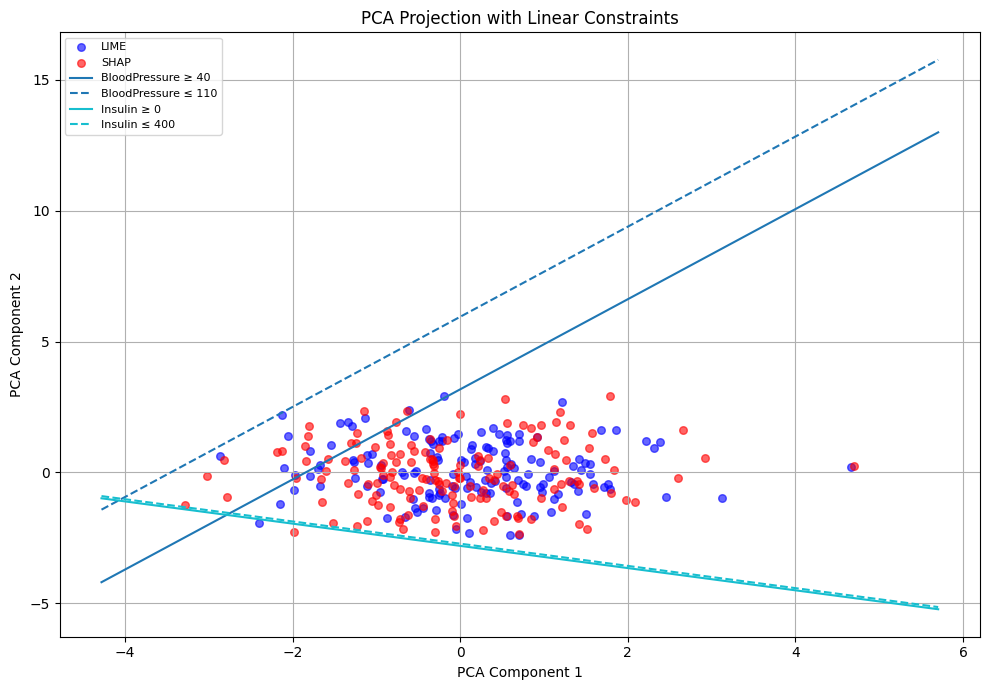

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.cm as cm

df1 = pd.read_csv("./cf samples/LIME_counterfactuals_ds2.csv")
df2 = pd.read_csv("./cf samples/SHAP_counterfactuals_ds2.csv")
df1 = df1.drop(columns=["source_index"], errors="ignore")
df2 = df2.drop(columns=["source_index"], errors="ignore")
df1["source"] = "LIME"
df2["source"] = "SHAP"
combined_df = pd.concat([df1, df2], ignore_index=True)

modifiable_bounds = {
    'BloodPressure': (40, 110),
    'Insulin': (0, 400),
}

feature_cols = [col for col in combined_df.columns if col != "source"]
X = combined_df[feature_cols].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca = PCA(n_components=2)
Z = pca.fit_transform(X_scaled)
W = pca.components_.T  
z1_range = np.linspace(Z[:, 0].min() - 1, Z[:, 0].max() + 1, 500)

plt.figure(figsize=(10, 7))
for label, color in zip(["LIME", "SHAP"], ["blue", "red"]):
    idx = combined_df["source"] == label
    plt.scatter(Z[idx, 0], Z[idx, 1], c=color, label=label, alpha=0.6, s=30)

colors = cm.get_cmap('tab10', len(modifiable_bounds))
linestyles = ['-', '--']  

for i, (feature, (lower, upper)) in enumerate(modifiable_bounds.items()):
    if feature not in feature_cols:
        continue
    f_idx = feature_cols.index(feature)
    f_mean = X[:, f_idx].mean()
    f_std = X[:, f_idx].std()

    lower_std = (lower - f_mean) / f_std
    upper_std = (upper - f_mean) / f_std

    a_lower = np.zeros(len(feature_cols)); a_lower[f_idx] = -1
    a_upper = np.zeros(len(feature_cols)); a_upper[f_idx] = 1
    proj_lower = a_lower @ W
    proj_upper = a_upper @ W

    z2_lower = (lower_std - proj_lower[0] * z1_range) / (proj_lower[1] + 1e-9)
    z2_upper = (upper_std - proj_upper[0] * z1_range) / (proj_upper[1] + 1e-9)

    plt.plot(z1_range, z2_lower, linestyle=linestyles[0], color=colors(i), label=f"{feature} ≥ {lower}")
    plt.plot(z1_range, z2_upper, linestyle=linestyles[1], color=colors(i), label=f"{feature} ≤ {upper}")

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("PCA Projection with Linear Constraints")
plt.legend(loc="best", fontsize=8)
plt.grid(True)
plt.tight_layout()
plt.show()

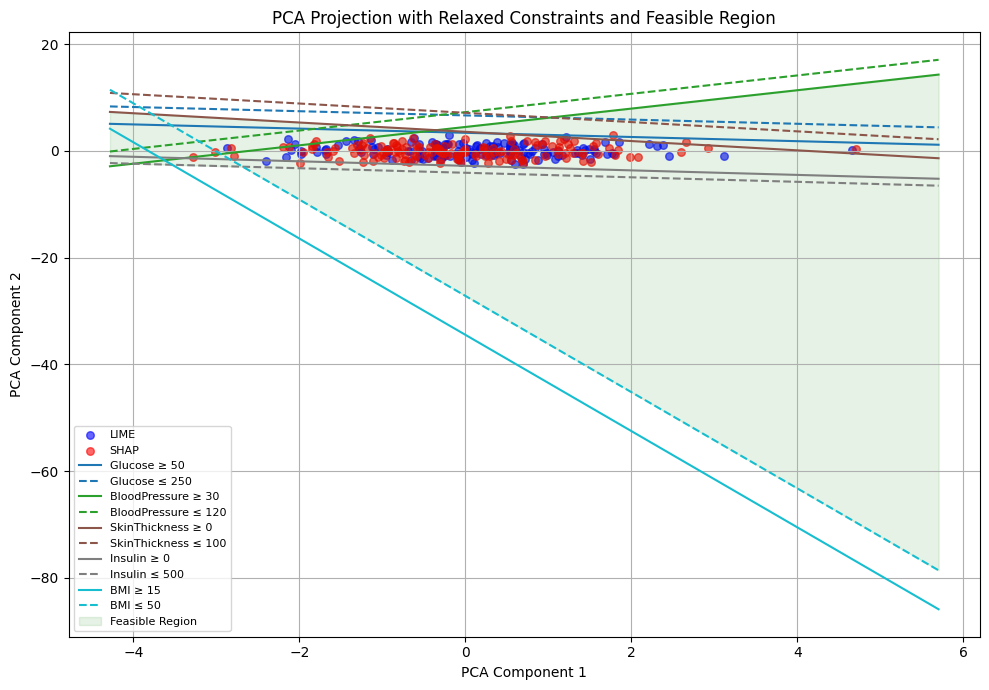

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.cm as cm

df1 = pd.read_csv("./cf samples/LIME_counterfactuals_ds2.csv")
df2 = pd.read_csv("./cf samples/SHAP_counterfactuals_ds2.csv")
df1 = df1.drop(columns=["source_index"], errors="ignore")
df2 = df2.drop(columns=["source_index"], errors="ignore")
df1["source"] = "LIME"
df2["source"] = "SHAP"
combined_df = pd.concat([df1, df2], ignore_index=True)

modifiable_bounds = {
    'Glucose': (50, 250),
    'BloodPressure': (30, 120),
    'SkinThickness': (0, 100),
    'Insulin': (0, 500),
    'BMI': (15, 50)
}

feature_cols = [col for col in combined_df.columns if col != "source"]
X = combined_df[feature_cols].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca = PCA(n_components=2)
Z = pca.fit_transform(X_scaled)
W = pca.components_.T
z1_range = np.linspace(Z[:, 0].min()-1, Z[:, 0].max()+1, 500)

plt.figure(figsize=(10, 7))
for label, color in zip(["LIME", "SHAP"], ["blue", "red"]):
    idx = combined_df["source"] == label
    plt.scatter(Z[idx, 0], Z[idx, 1], c=color, label=label, alpha=0.6, s=30)

colors = cm.get_cmap('tab10', len(modifiable_bounds))
linestyles = ['-', '--']
upper_bounds = []
lower_bounds = []

for i, (feature, (lower, upper)) in enumerate(modifiable_bounds.items()):
    if feature not in feature_cols:
        continue

    f_idx = feature_cols.index(feature)
    f_mean = X[:, f_idx].mean()
    f_std = X[:, f_idx].std()
    lower_std = (lower - f_mean) / f_std
    upper_std = (upper - f_mean) / f_std

    a_lower = np.zeros(len(feature_cols)); a_lower[f_idx] = -1
    a_upper = np.zeros(len(feature_cols)); a_upper[f_idx] = 1
    proj_lower = a_lower @ W
    proj_upper = a_upper @ W

    z2_lower = (lower_std - proj_lower[0] * z1_range) / (proj_lower[1] + 1e-9)
    z2_upper = (upper_std - proj_upper[0] * z1_range) / (proj_upper[1] + 1e-9)

    lower_bounds.append(z2_lower)
    upper_bounds.append(z2_upper)

    plt.plot(z1_range, z2_lower, linestyle=linestyles[0], color=colors(i), label=f"{feature} ≥ {lower}")
    plt.plot(z1_range, z2_upper, linestyle=linestyles[1], color=colors(i), label=f"{feature} ≤ {upper}")

final_lower = np.maximum.reduce(lower_bounds)
final_upper = np.minimum.reduce(upper_bounds)
plt.fill_between(z1_range, final_lower, final_upper, color='green', alpha=0.1, label='Feasible Region')

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("PCA Projection with Relaxed Constraints and Feasible Region")
plt.legend(loc="best", fontsize=8)
plt.grid(True)
plt.tight_layout()
plt.show()


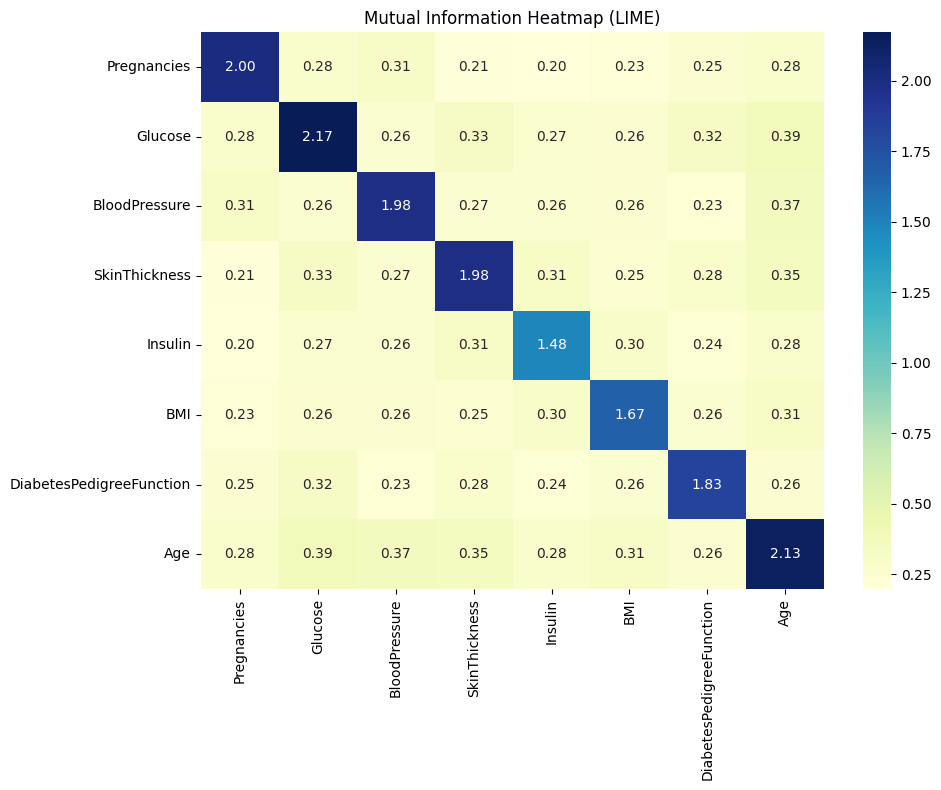

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mutual_info_score

feature_cols = [col for col in df1.columns if col not in ["source"]]
X = df1[feature_cols]

d = X.shape[1]
mi_matrix = np.zeros((d, d))
for i in range(d):
    for j in range(d):
        bins_i = np.linspace(X.iloc[:, i].min(), X.iloc[:, i].max(), 11)
        bins_j = np.linspace(X.iloc[:, j].min(), X.iloc[:, j].max(), 11)
        xi = np.digitize(X.iloc[:, i], bins_i)
        xj = np.digitize(X.iloc[:, j], bins_j)
        mi_matrix[i, j] = mutual_info_score(xi, xj)

plt.figure(figsize=(10, 8))
sns.heatmap(mi_matrix, annot=True, fmt=".2f", cmap="YlGnBu", 
            xticklabels=feature_cols, yticklabels=feature_cols)
plt.title("Mutual Information Heatmap (LIME)")
plt.tight_layout()
plt.show()

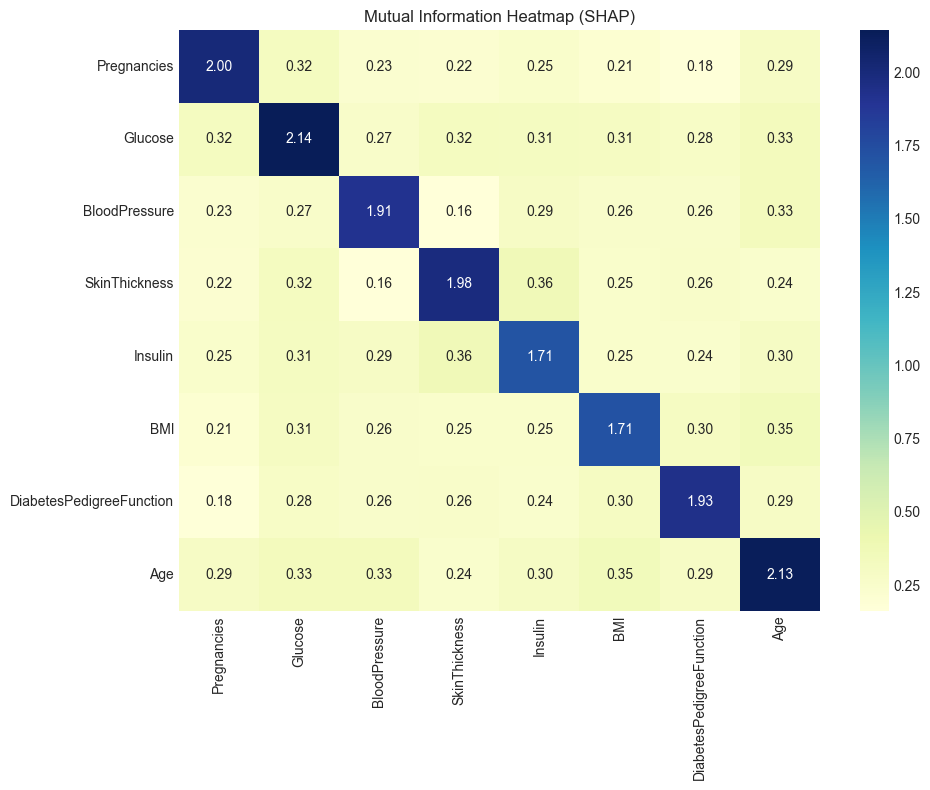

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mutual_info_score

feature_cols = [col for col in df2.columns if col not in ["source"]]
X = df2[feature_cols]

d = X.shape[1]
mi_matrix = np.zeros((d, d))
for i in range(d):
    for j in range(d):
        bins_i = np.linspace(X.iloc[:, i].min(), X.iloc[:, i].max(), 11)
        bins_j = np.linspace(X.iloc[:, j].min(), X.iloc[:, j].max(), 11)
        xi = np.digitize(X.iloc[:, i], bins_i)
        xj = np.digitize(X.iloc[:, j], bins_j)
        mi_matrix[i, j] = mutual_info_score(xi, xj)

plt.figure(figsize=(10, 8))
sns.heatmap(mi_matrix, annot=True, fmt=".2f", cmap="YlGnBu", 
            xticklabels=feature_cols, yticklabels=feature_cols)
plt.title("Mutual Information Heatmap (SHAP)")
plt.tight_layout()
plt.show()

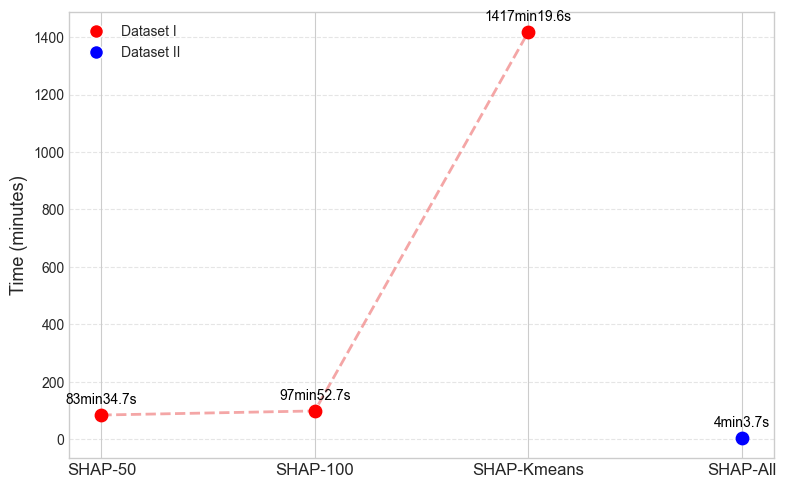

In [29]:
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('seaborn-whitegrid')
plt.figure(figsize=(8, 5))

labels = ["SHAP-50", "SHAP-100", "SHAP-Kmeans", "SHAP-All"]
x = np.arange(len(labels))

# 数据
ds1_times = [83 + 34.7 / 60, 97 + 52.7 / 60, 1417 + 19.6 / 60, None]
ds1_plot = [t if t is not None else np.nan for t in ds1_times]
ds2_times = [None, None, None, 4 + 3.7 / 60]
ds2_plot = [t if t is not None else np.nan for t in ds2_times]

# 淡红色虚线 (alpha=0.5)
plt.plot(x, ds1_plot, marker='o', color='#f08080', linestyle='--', linewidth=2, label='Dataset I', alpha=0.7)
plt.plot(x, ds2_plot, marker='o', color='#f08080', linestyle='--', linewidth=2, label='Dataset II', alpha=0.7)

# 点的颜色
plt.scatter(x[:3], ds1_plot[:3], color='red', s=80, zorder=3, label='Dataset I Points')
plt.scatter(x[3:], ds2_plot[3:], color='blue', s=80, zorder=3, label='Dataset II Point')

# 注释全部黑色
ds1_labels = ["83min34.7s", "97min52.7s", "1417min19.6s", ""]
ds2_labels = ["", "", "", "4min3.7s"]

for i, (y1, y2) in enumerate(zip(ds1_plot, ds2_plot)):
    if not np.isnan(y1):
        plt.text(i, y1 + 30, ds1_labels[i], ha='center', va='bottom', fontsize=10, color='black')
    if not np.isnan(y2):
        plt.text(i, y2 + 30, ds2_labels[i], ha='center', va='bottom', fontsize=10, color='black')

plt.xticks(x, labels, fontsize=12)
plt.ylabel("Time (minutes)", fontsize=13)
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

# 点的图例
handles = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=10, label='Dataset I'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=10, label='Dataset II')
]
plt.legend(handles=handles, loc='upper left')

plt.savefig("shap_runtime_lightred.pdf", dpi=300)
plt.show()


This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


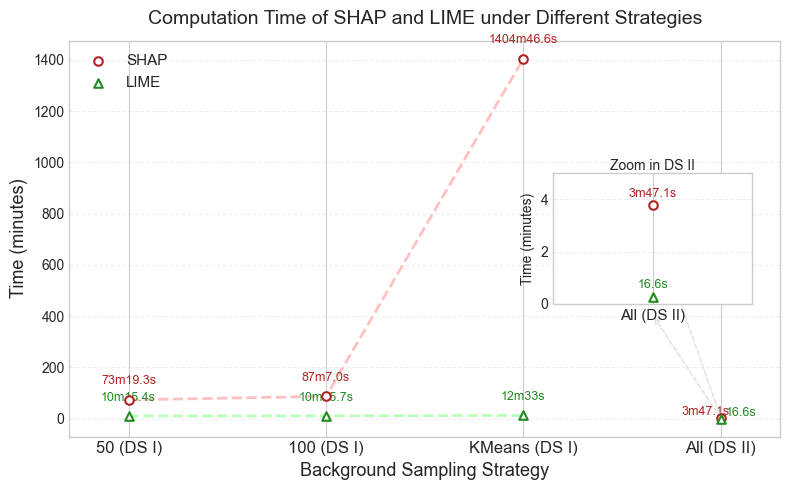

In [52]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

xticks = ['50 (DS I)', '100 (DS I)', 'KMeans (DS I)', 'All (DS II)']
x = np.arange(len(xticks))
shap_times = [73 + 19.3/60, 87 + 7.0/60, 1404 + 46.6/60, 3 + 47.1/60]
lime_times  = [10 + 15.4/60, 10 + 45.7/60, 12 + 33/60, 16.6/60]
lime_labels = ["10m15.4s", "10m45.7s", "12m33s", "16.6s"]
shap_labels = ["73m19.3s", "87m7.0s", "1404m46.6s", "3m47.1s"]

shap_color = 'firebrick'
lime_color = 'forestgreen'
shap_light = '#FFC0C0'
lime_light = '#B8FFB8'
arrow_gray = '#E0E0E0'

fig, ax = plt.subplots(figsize=(8, 5))

# Dataset I 折线
ax.plot(x[:3], shap_times[:3], linestyle='--', color=shap_light, linewidth=2, marker=None, label=None)
ax.scatter(x[:3], shap_times[:3], color='white', edgecolors=shap_color, marker='o',
           s=38, linewidths=1.5, zorder=10, label='SHAP')
for xi, yi, txt in zip(x[:3], shap_times[:3], shap_labels[:3]):
    ax.text(xi, yi+60, txt, color=shap_color, fontsize=9, ha='center')
ax.plot(x[:3], lime_times[:3], linestyle='--', color=lime_light, linewidth=2, marker=None, label=None)
ax.scatter(x[:3], lime_times[:3], color='white', edgecolors=lime_color, marker='^',
           s=38, linewidths=1.5, zorder=10, label='LIME')
for xi, yi, txt in zip(x[:3], lime_times[:3], lime_labels[:3]):
    ax.text(xi, yi+60, txt, color=lime_color, fontsize=9, ha='center')

# Dataset II 独立点
ax.scatter(x[3], shap_times[3], color='white', edgecolors=shap_color, marker='o',
           s=38, linewidths=1.5, zorder=10) # , label='SHAP (Dataset II)'
ax.scatter(x[3], lime_times[3], color='white', edgecolors=lime_color, marker='^',
           s=38, linewidths=1.5, zorder=10) # label='LIME (Dataset II)'
ax.text(x[3]-0.08, shap_times[3]+10, shap_labels[3], color=shap_color, fontsize=9, ha='center')
ax.text(x[3]+0.10, lime_times[3]+10, lime_labels[3], color=lime_color, fontsize=9, ha='center')

ax.set_xticks(x)
ax.set_xticklabels(xticks, fontsize=12)
ax.set_xlim(-0.3, 3.3)
ax.set_ylabel("Time (minutes)", fontsize=13)
ax.set_xlabel("Background Sampling Strategy", fontsize=13)
ax.set_title("Computation Time of SHAP and LIME under Different Strategies", fontsize=14, pad=12)
ax.legend(fontsize=11, loc='upper left')
ax.grid(axis='y', alpha=0.3, linestyle='--')

# --- inset: 主图右侧中间 ---
inset = inset_axes(ax, width="28%", height="33%", loc='center right', borderpad=2)
inset.scatter(3, shap_times[3], color='white', edgecolors=shap_color, marker='o',
              s=38, linewidths=1.5, zorder=10)
inset.scatter(3, lime_times[3], color='white', edgecolors=lime_color, marker='^',
              s=38, linewidths=1.5, zorder=10)
# 注释在点正上方
inset.text(3, shap_times[3]+0.20, shap_labels[3], color=shap_color, fontsize=9, ha='center', va='bottom')
inset.text(3, lime_times[3]+0.20, lime_labels[3], color=lime_color, fontsize=9, ha='center', va='bottom')
inset.set_xlim(2.85, 3.15)
inset.set_xticks([3])
inset.set_xticklabels(['All (DS II)'], fontsize=11)
inset.set_ylim(0, 5)
inset.set_ylabel('Time (minutes)', fontsize=10)
inset.grid(axis='y', alpha=0.3, linestyle='--')
inset.set_title("Zoom in DS II", fontsize=10, pad=2)

# --- 更垂直的浅灰虚线 ---
# SHAP主图点到inset点下方
ax.annotate(
    '', xy=(3, shap_times[3]-0.7), xycoords=inset.transData,
    xytext=(x[3], shap_times[3]), textcoords=ax.transData,
    arrowprops=dict(arrowstyle="->", color=arrow_gray, linestyle='--', linewidth=1.0, shrinkA=0, shrinkB=2),
    annotation_clip=False
)
# LIME主图点到inset点下方
ax.annotate(
    '', xy=(3, lime_times[3]-0.7), xycoords=inset.transData,
    xytext=(x[3], lime_times[3]), textcoords=ax.transData,
    arrowprops=dict(arrowstyle="->", color=arrow_gray, linestyle='--', linewidth=1.0, shrinkA=0, shrinkB=2),
    annotation_clip=False
)

plt.tight_layout()
plt.show()
